<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2024-2/Sesiones/Sesion_16_Reduccion_Dimensionalidad_PCA_Perm_IV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import scipy as sp
import matplotlib.pylab as plt

# Reduccion de dimensionalidad

In [ ]:
''' Ejemplo de data set sintético con variables aleatorias y variables relacionadas '''
n = 100

# Variable causal con ruido gausiano pequeño
x1 = np.linspace(-1, 1,n) + np.random.RandomState().normal(0, 0.05, n)

# Variable causal con un ruido grande uniforme
x2 = np.linspace(-1, 1,n) + np.random.RandomState().uniform(-0.5, 0.5, n)

# Variable pura aleatoria gausiana
x3 = np.random.RandomState().normal(0, 1, n)

# Variable pura aleatoria uniforme
x4 =  np.random.RandomState().uniform(0, 1, n)

# target y = 5x + ruido
y = np.array([0]*(n//2) + [1]*(n // 2))
#y =5*np.linspace(-1, 1,n) + np.random.RandomState().normal(0, 0.1, n)


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

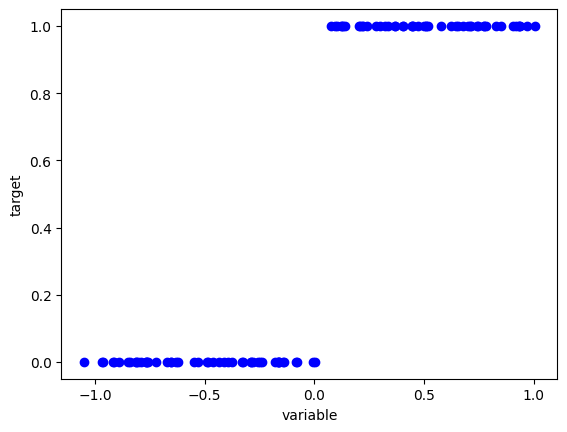

In [ ]:
# verifiquen como se ve la relación entre cada x y el target y
plt.figure()
plt.plot(x1, y, "bo")
plt.xlabel("Variable Cuasal con ruido gausiano pequeño")
plt.ylabel("target")
plt.show()

## Permutation Test para clasificadores
https://www.jmlr.org/papers/volume11/ojala10a/ojala10a.pdf

Este test nos permite encontrar variables que están muy poco correlacionadas con la variable objetivo. Se basa en un test combinatorio por lo cual a pesar de ser un test riguroso es difícil de aplicar a datasets muy grandes.


In [ ]:
from sklearn.model_selection import permutation_test_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [ ]:
# remodelar para la prueba
x1_perm = x1.reshape(-1,1)
x2_perm = x2.reshape(-1,1)
x3_perm = x3.reshape(-1,1)
x4_perm = x4.reshape(-1,1)

x1_perm.shape

(100, 1)

### Función `permutation_test_score`

Permite evaluar si el rendimiento de un modelo (según una métrica de interés) es estadísticamente significativo o podría ser producto de la casualidad.

Realiza un test de permutación sobre las etiquetas de entrenamiento, estimando la distribución de la métrica de manera empírica y comparándola con la puntuación real del modelo (sin permutar).

\
1. Calcula la métrica con las etiquetas originales, obteniendo una “score real”.

2. Permutaciones:

  * Mezcla (permuta) aleatoriamente las etiquetas de la variable objetivo manteniendo los atributos fijos.

  * Cada vez, entrena y evalúa el modelo con estas etiquetas permutadas, obteniendo una score.

  * Repite el proceso varias veces (controlado por `n_permutations`), generando una distribución de scores “al azar”.

3. P-valor:

  * Indica qué proporción de las permutaciones produce una score igual o superior (o igual o inferior, según la hipótesis) a la obtenida con las etiquetas reales.

  * Mientras más bajo sea el valor p, menor la probabilidad de que el resultado se deba al azar.

\
**Parámetros:**

* `estimator` : Modelo o pipeline que tenga implementado un método `fit` y `score`.

* `X, y, cv (validación cruzada), scoring (métrica), n_jobs, random_state`

* `n_permutations (int, 100)`: Número de permutaciones (aleatorizaciones de etiquetas) que se realizan para estimar la distribución empírica de la puntuación.

\
**Retorna:**

* `score`: puntuación de la muestra original.

* `permutation_scores`: array de las puntuaciones en cada permutación.

* `pvalue`: probabilidad de observar una puntuación igual o mayor al `score` original, bajo permutaciones de `y`.

In [ ]:
def permutation_test(x,y):
    estimator = LogisticRegression()
    score, permutation_scores, pvalue = permutation_test_score(
      estimator, x, y, random_state=0
    )
    print(f"Original Score: {score:.3f}")
    print(
        f"Permutation Scores (Empiric): {permutation_scores.mean():.3f} +/- "
        f"{permutation_scores.std():.3f}"
        )
    print(f"P-value: {pvalue:.3f}")
    return None

In [ ]:
print('----------- Prueba de permutación para la clisificación de algunos tipos de variables -----------')

print("\nX1 -> Variable Causal con ruido gaussiano pequeño")
permutation_test(x1_perm, y)

print("\nX2 -> Variable causal con un ruido grande uniforme")
permutation_test(x2_perm, y)

print("\nX3 -> Variable causal con un ruido grande uniforme")
permutation_test(x3_perm, y)

print("\nX4 -> Variable pura aleatoria uniforme")
permutation_test(x4_perm, y)

----------- Prueba de permutación para la clisificación de algunos tipos de variables -----------

X1 -> Variable Causal con ruido gaussiano pequeño
Original Score: 0.940
Permutation Scores (Empiric): 0.525 +/- 0.034
P-value: 0.010

X2 -> Variable causal con un ruido grande uniforme
Original Score: 0.820
Permutation Scores (Empiric): 0.511 +/- 0.039
P-value: 0.010

X3 -> Variable causal con un ruido grande uniforme
Original Score: 0.420
Permutation Scores (Empiric): 0.491 +/- 0.060
P-value: 0.901

X4 -> Variable pura aleatoria uniforme
Original Score: 0.470
Permutation Scores (Empiric): 0.494 +/- 0.056
P-value: 0.624


El **P-valor** representa la fracción de conjuntos de datos aleatorios en los que el estimador funcionó tan bien o mejor que en los datos originales.

* Un P-valor pequeño sugiere que existe una dependencia real entre las características y los (targets) objetivos que el estimador ha utilizado para ofrecer buenas predicciones.

* Un P-valor elevado puede deberse a la falta de dependencia real entre las características y los targets (objetivos) o a que el estimador no ha sido capaz de utilizar la dependencia para obtener buenas predicciones.

\
**Observación de resultados:**

Basados en el bajo P-valor de $X_1$ y $X_2$ versus el alto P-valor de $X_3$ y $X_4$ podemos reducir el número de variables a $X_1$ y $X_2$ al demostrar estas mayor dependencia con la variable objetivo y permitir una mejor clasificación.


## Principal Component Analysis PCA

El análisis de componentes principales (PCA) es una técnica estadística que se utiliza para reducir la dimensionalidad de un conjunto de datos, es decir, para representar los datos con menos variables sin perder mucha información. El PCA busca las combinaciones lineales de las variables originales que capturan la mayor parte de la variación o la dispersión de los datos. Estas combinaciones se llaman componentes principales, y se ordenan de mayor a menor importancia. El PCA se puede usar para explorar la estructura de los datos, para visualizarlos en un espacio de baja dimensión, o para prepararlos para otros análisis como la regresión o la clasificación.

Para entender mejor el PCA, puedes consultar la sección 3.2.1 y el apendice A de https://arxiv.org/pdf/2204.04198



Promedios de las variables
-2.2204460492503132e-17 0.13683554405219717
-2.2204460492503132e-17 2.2204460492503132e-17


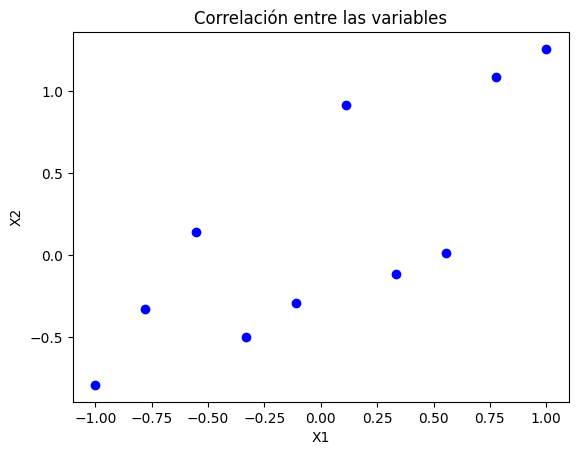

In [ ]:
# Consideremos dos características que constituyen una data centrada en cero
X1 = np.linspace(-1, 1,10)
X2 = np.linspace(-1, 1,10) + (2*np.random.random(10)-1)   # Con sesgo

print('Promedios de las variables')
print(X1.mean(), X2.mean())
x_1 = X1 - X1.mean()
x_2 = X2 - X2.mean()
print(x_1.mean(), x_2.mean())

plt.figure()
plt.title('Correlación entre las variables')
plt.plot(X1, X2,"bo")
plt.xlabel(r"$X_1$")
plt.ylabel(r"$X_2$")
plt.show()

In [ ]:
X = np.stack((X1, X2), axis=0)    # Matriz con las dos variables
X, X.shape

array([[-1.        , -0.77777778, -0.55555556, -0.33333333, -0.11111111,
         0.11111111,  0.33333333,  0.55555556,  0.77777778,  1.        ],
       [-0.79274837, -0.32731169,  0.13722251, -0.50350477, -0.29598047,
         0.91322736, -0.11694056,  0.0138602 ,  1.08515634,  1.25537489]])

In [ ]:
A = np.cov(X)   # Matriz de covarianza
A

array([[0.4526749 , 0.37126512],
       [0.37126512, 0.50107517]])

In [ ]:
M = np.matrix(A)    # La convertimos a un objeto 'matrix'
M

matrix([[0.4526749 , 0.37126512],
        [0.37126512, 0.50107517]])

In [ ]:
# Autovalores y matriz de autovectores
E,U = np.linalg.eig(M)
E,U

(array([0.10482204, 0.84892803]),
 matrix([[-0.72974135, -0.68372331],
         [ 0.68372331, -0.72974135]]))

En el contexto del Análisis de Componentes Principales (PCA):

* La matriz $M$ representa la matriz de covarianza de los datos.

* Los autovectores en $U$ representan las direcciones (o componentes principales) en las que los datos tienen la mayor varianza.

* Los autovalores en $E$ representan la magnitud de la varianza en cada dirección principal.

In [ ]:
U1 = np.array(U[:,0])
U2 = np.array(U[:,1])

U1, U2

(array([[-0.72974135],
        [ 0.68372331]]),
 array([[-0.68372331],
        [-0.72974135]]))

In [ ]:
#comparar a M
#r = (np.matrix(X) @ np.matrix(X).T) /10

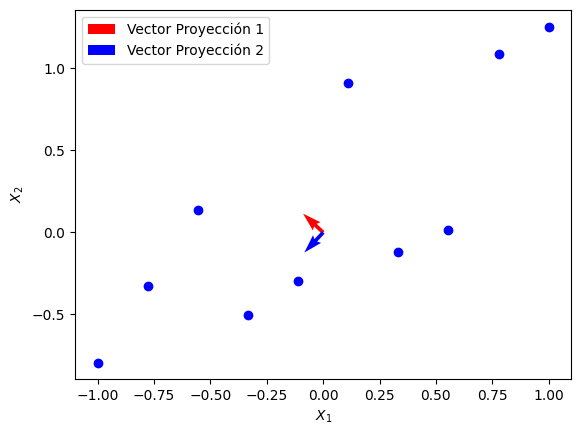

In [ ]:
plt.figure()
plt.plot(X1, X2,"bo")
plt.quiver(0,0,U1[0][0],U1[1][0], color='r', label="Vector Proyección 1")
plt.quiver(0,0,U2[0][0],U2[1][0], color='b', label="Vector Proyección 2")
plt.xlabel(r"$X_1$")
plt.ylabel(r"$X_2$")
plt.legend()
plt.show()

In [ ]:
''' Usamos U2 como eje principal -> proyectamos X en dicho nuevo sistema '''
# Proyectamos los datos X en el subespacio reducido de manera que queda una sola variable P
P = U2.T@X
P

array([[ 1.26222457,  0.77063767,  0.27970935,  0.59533602,  0.29195845,
        -0.74238902, -0.14257141, -0.38996065, -1.32366825, -1.59982227]])

In [ ]:
# Pendiente de la línea para el cual U2 es vector director
m = np.arctan(U2[1][0]/U2[0][0])
m

0.8179435734838126

In [ ]:
''' Representamos X2 en términos del eje X1 y la pendiente m '''
X2r = X1*np.tan(m)
X2r

array([-1.06730506, -0.83012615, -0.59294725, -0.35576835, -0.11858945,
        0.11858945,  0.35576835,  0.59294725,  0.83012615,  1.06730506])

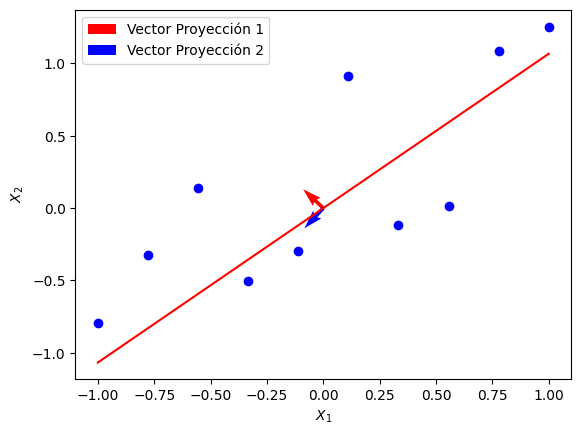

In [ ]:
plt.figure()
plt.plot(X1, X2,"bo")
plt.quiver(0,0,U1[0][0],U1[1][0], color='r', label="Vector Proyección 1")
plt.quiver(0,0,U2[0][0],U2[1][0], color='b', label="Vector Proyección 2")
plt.plot(X1, X2r,"r-")
plt.xlabel(r"$X_1$")
plt.ylabel(r"$X_2$")
plt.legend()
plt.show()

Observamos que los datos tienen la mayor varianza posible sobre la proyección del primer vector. Esta es una propiedad algebraica que se puede aprovechar para decidir quedarse con los datos proyectados sobre un subespacio más pequeño que el original con una varianza mayor a ciertdo valor treshold.

### Algoritmo: Principal component analysis (PCA)

El algoritmo quedaría de esta manera (tomado de la referencia indicada arriba):

**Requiere:**

* Hiperparámetro $k$ (la dimensionalidad de los datos proyectados)

  En el ejemplo anterior de dos dimensiones que se pueden reducir a una dimension escogeriamos k=1.

* Matriz X ∈ $R_{n×m}$

  * $n$: Número de variables.
  * $m$: Número de datos.

  En el ejemplo anterior de los datos m=2 variables con cada una n=10 records  

**Pasos:**

1. En este paso transformamos las variables de manera que cada variable esté centrada en cero:
  X ← X − mean(X)

2. Construimos la matriz de covarianza empírica Σ a partir de XᵀX/n

  **Fórmula de la matriz de covarianza (concepto)**

  Para **2 variables**, la matriz de covarianza \( \Sigma \) tiene la forma:

  $$
  \Sigma = \begin{pmatrix}
  \mathrm{Var}(X_1) & \mathrm{Cov}(X_1, X_2) \\
  \mathrm{Cov}(X_2, X_1) & \mathrm{Var}(X_2)
  \end{pmatrix},
  $$

  donde:

  $$
  \mathrm{Var}(X_1)
  = \frac{1}{n-1} \sum_{j=1}^{m} \bigl(x_{1,j} - \overline{x_1}\bigr)^2,
  \quad
  \mathrm{Var}(X_2)
  = \frac{1}{n-1} \sum_{j=1}^{m} \bigl(x_{2,j} - \overline{x_2}\bigr)^2,
  \quad
  \mathrm{Cov}(X_1, X_2)
  = \frac{1}{n-1} \sum_{j=1}^{m} \bigl(x_{1,j} - \overline{x_1}\bigr)\,\bigl(x_{2,j} - \overline{x_2}\bigr).
  $$

  - $m=10$ es el número de observaciones por cada variable.  
  - $\overline{x_1}$ y $\overline{x_2}$ son las medias de la variable 1 y 2, respectivamente.

3. Calculamos los vectores propios de la matriz de covarianza y los ordenamos por el valor de mayor a menor de sus valores propios:
  V ← Eigenvectors(Σ)

4. Construimos la matriz $\tilde V$ ∈ Rm×k para hacer la proyección en el espacio reducido de los primeros $k$-vectores propios
  $\tilde V$ ← V [:, :k]

5. Proyectamos los datos $X$ en el espacio reducido para retornar $\tilde X$:

  $\tilde X$ ← X $\tilde V$ ∈ Rn×k

### PCA con Sklearn

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

Forma de X original: (150, 4)
Forma de X tras PCA: (150, 2)
Varianza explicada por cada componente: [0.92461872 0.05306648]



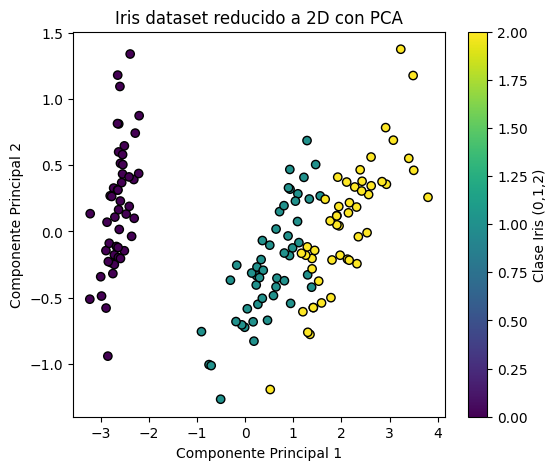

In [ ]:
# 1. Cargar los datos (Iris tiene 4 características y 3 clases)
iris = load_iris()
X = iris.data     # Matriz de características (150 x 4)
y = iris.target   # Etiquetas (150, con valores 0,1,2)

print("Forma de X original:", X.shape)

# 2. Crear el objeto PCA para reducir a 2 dimensiones
pca = PCA(n_components=2)

# 3. Ajustar PCA a los datos y transformarlos
X_pca = pca.fit_transform(X)
print("Forma de X tras PCA:", X_pca.shape)

# Imprime la varianza explicada por cada componente
print("Varianza explicada por cada componente:", pca.explained_variance_ratio_)
print()

# 4. Visualizar los datos reducidos (2D)
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolor='k')
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Iris dataset reducido a 2D con PCA")
plt.colorbar(label="Clase Iris (0,1,2)")
plt.show()